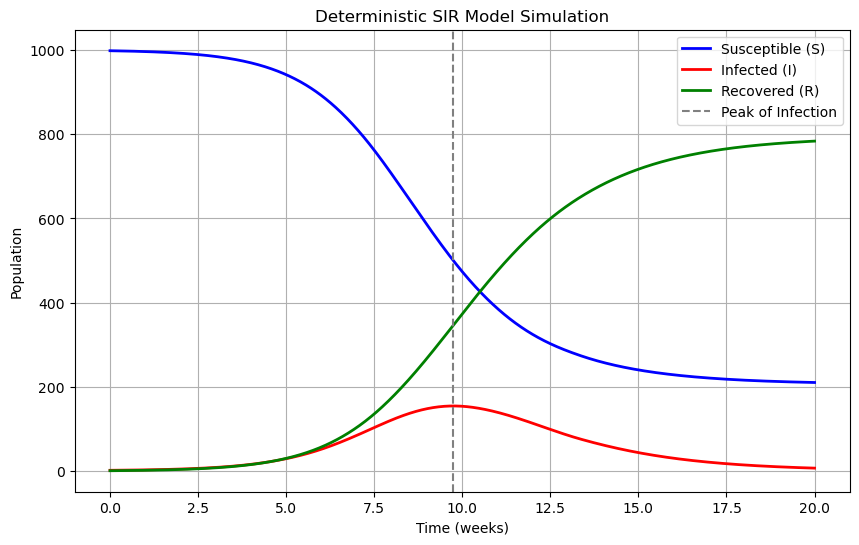

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

a = 2 * np.log(2)  #Infection rate
b = np.log(2)      #Recovery rate 
N = 1000           #Total population

def sir_model(t, y):
    S, I, R = y
    dSdt = - (a / N) * I * S
    dIdt = (a / N) * I * S - b * I
    dRdt = b * I
    return [dSdt, dIdt, dRdt]

y0 = [999, 1, 0]
t_span = (0, 20)   #Time interval
t_eval = np.linspace(0, 20, 1000)

solution = solve_ivp(sir_model, t_span, y0, t_eval=t_eval)

plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], label='Susceptible (S)', color='blue', linewidth=2)
plt.plot(solution.t, solution.y[1], label='Infected (I)', color='red', linewidth=2)
plt.plot(solution.t, solution.y[2], label='Recovered (R)', color='green', linewidth=2)
plt.axvline(x=solution.t[np.argmax(solution.y[1])], color='gray', linestyle='--', label='Peak of Infection')
plt.xlabel('Time (weeks)')
plt.ylabel('Population')
plt.title('Deterministic SIR Model Simulation')
plt.legend()
plt.grid(True)
plt.show()

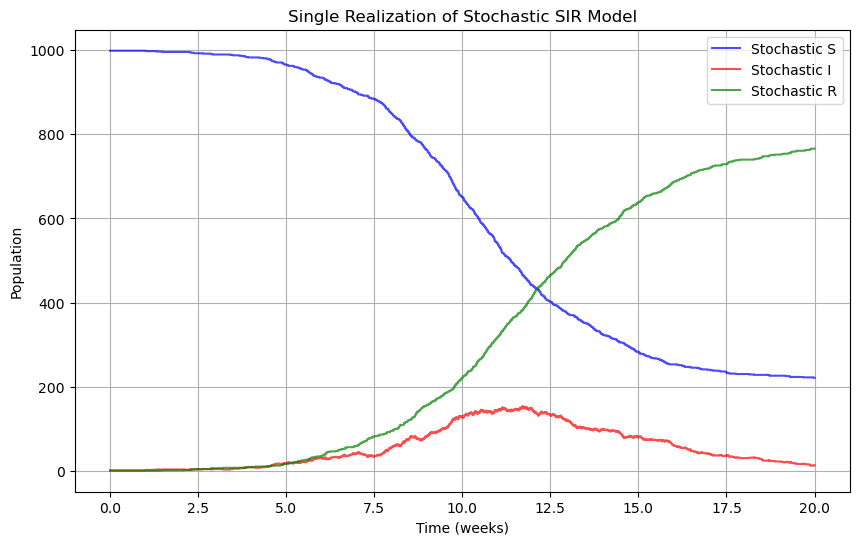

In [4]:
import numpy as np
import matplotlib.pyplot as plt

a = 2 * np.log(2)
b = np.log(2)
N = 1000
h = 0.001  #Small time step
t_max = 20
num_steps = int(t_max / h)

t = np.linspace(0, t_max, num_steps)
S = np.zeros(num_steps)
I = np.zeros(num_steps)
R = np.zeros(num_steps)

S[0], I[0], R[0] = 999, 1, 0

for k in range(0, num_steps - 1):
    S_curr, I_curr, R_curr = S[k], I[k], R[k]
    
    P_inf = (a / N) * I_curr * S_curr * h
    P_rec = b * I_curr * h
    
    u = np.random.rand()
    
    if u < P_inf and S_curr > 0:
        S[k+1] = S_curr - 1
        I[k+1] = I_curr + 1
        R[k+1] = R_curr
    elif u < (P_inf + P_rec) and I_curr > 0:
        S[k+1] = S_curr
        I[k+1] = I_curr - 1
        R[k+1] = R_curr + 1
    else:
        S[k+1] = S_curr
        I[k+1] = I_curr
        R[k+1] = R_curr

plt.figure(figsize=(10, 6))
plt.plot(t, S, label='Stochastic S', color='blue', alpha=0.7)
plt.plot(t, I, label='Stochastic I', color='red', alpha=0.7)
plt.plot(t, R, label='Stochastic R', color='green', alpha=0.7)
plt.xlabel('Time (weeks)')
plt.ylabel('Population')
plt.title('Single Realization of Stochastic SIR Model')
plt.legend()
plt.grid(True)
plt.show()